## 1. 데이터 불러오기

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

In [72]:
df = pd.read_csv("4.csv", low_memory=False)

## EBAY란?

이베이(eBay)는 개인과 기업이 상품을 사고팔 수 있는 온라인 마켓플레이스를 운영하는 글로벌 전자상거래 기업으로, 경매와 즉시 구매 옵션을 통해 다양한 제품을 거래할 수 있습니다. 주로 중고품, 희귀 아이템, 신제품 등이 거래되며, 전 세계 사용자들이 손쉽게 상품을 등록하고 구매할 수 있는 플랫폼을 제공합니다.

이베이 주식회사(영어: eBay lnc.)는 미국 캘리포니아주 새너제이에 본사가 있는 다국적 전자 상거래 기업으로 이베이 웹사이트에서 소비자 대 소비자 그리고 비즈니스 대 소비자 판매를 중개하고 있다. 이베이는 1995년 피에르 오미디야르에 의하여 설립되어 닷컴 버블의 주목할 만한 성공적인 사례로 꼽히고 있으며, 전 세계에서 다양한 종류의 물건과 서비스를 일반 개인과 사업체가 사고파는 사이트 이베이 닷컴(eBay.com)을 운영하고 있다. 구매자는 무료로 이용할 수 있으나 판매자는 제한된 수의 무료 리스팅 이후에 초과 리스팅들에 대하여 또한 물건이 판매된 이후 최종 가격의 일정 비율에 대하여 수수료를 부담해야 한다.


In [73]:
df = df.drop(columns='Unnamed: 0')

In [80]:
df.to_csv('5.csv')

## 1.1 분석 목적 및 변수 확인¶

In [74]:
# 데이터 프레임 변수 확인
df.columns

Index(['ItemId', 'title', 'krw_price', 'price', 'currency', 'marketingPrice',
       'conditionEnumValue', 'condition', 'conditionId', 'adultOnly',
       'availableCoupons', 'buyingOptions', 'customerCountry',
       'customerCountryCode', 'image', 'itemWebUrl', 'itemLocation',
       'itemOriginDate', 'itemCreationDate', 'priorityListing',
       'topRatedBuyingExperience', 'categoryMainName', 'categoryMainId',
       'leafCategoryName_L3', 'leafCategoryId_L3', 'listingMarketplaceId',
       'sellerUsername', 'sellerFeedbackPercentage', 'sellerFeedbackScore',
       'sellerAccountType', 'shippingCostType', 'shippingCostValue',
       'shippingCostCurrency', 'itemLocation_nonmask', 'areaCode', 'state'],
      dtype='object')

In [75]:
# 행/열 개수
df.shape

(785349, 36)

In [79]:
df.isnull().sum()

ItemId                           0
title                            0
krw_price                        0
price                            0
currency                         0
marketingPrice              701455
conditionEnumValue               0
condition                        0
conditionId                      0
adultOnly                        0
availableCoupons                 0
buyingOptions                    0
customerCountry                  0
customerCountryCode              0
image                            0
itemWebUrl                       0
itemLocation                     0
itemOriginDate                   0
itemCreationDate                 0
priorityListing                  0
topRatedBuyingExperience         0
categoryMainName                 0
categoryMainId                   0
leafCategoryName_L3              0
leafCategoryId_L3                0
listingMarketplaceId             0
sellerUsername                   0
sellerFeedbackPercentage         0
sellerFeedbackScore 

In [58]:
# 데이터 구조 확인
df.info() #변수 타입 및 결측치 개수 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785349 entries, 0 to 785348
Data columns (total 36 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ItemId                    785349 non-null  int64  
 1   title                     785349 non-null  object 
 2   krw_price                 785349 non-null  int64  
 3   price                     785349 non-null  float64
 4   currency                  785349 non-null  object 
 5   marketingPrice            83894 non-null   object 
 6   conditionEnumValue        785349 non-null  object 
 7   condition                 785349 non-null  object 
 8   conditionId               785349 non-null  int64  
 9   adultOnly                 785349 non-null  bool   
 10  availableCoupons          785349 non-null  bool   
 11  buyingOptions             785349 non-null  object 
 12  customerCountry           785349 non-null  object 
 13  customerCountryCode       785349 non-null  i

In [59]:
# 범주형 변수 요약
df.describe(include='object')

,title,currency,marketingPrice,conditionEnumValue,condition,buyingOptions,customerCountry,image,itemWebUrl,itemLocation,...,leafCategoryName_L3,listingMarketplaceId,sellerUsername,sellerAccountType,shippingCostType,shippingCostValue,shippingCostCurrency,itemLocation_nonmask,areaCode,state
count,785349,785349,83894,785349,785349,785349,785349,785349,785349,785349,...,785349,785349,785349,785349,785349,785349,785349,762386,785349,785349
unique,752331,3,46643,17,32,3,7,766606,785349,4477,...,3655,8,182942,3,3,10430,4,4403,1194,154
top,Workout Gym Fitness muscle Quotes Quality pos...,USD,{'discountPercentage': '0'},NEW,new,FIXED_PRICE,US,unknown,https://www.ebay.co.uk/itm/274576864379?hash=i...,unknown,...,DVDs & Blu-ray Discs,EBAY_US,musicmagpie,unknown,FIXED,0.0,AUD,unknown,UNKNOWN,England
freq,291,273605,9140,528479,352484,608013,332821,1158,1,129745,...,25105,334720,9584,564977,712362,519260,260732,129745,152713,173181


In [60]:
pd.set_option('display.float_format', '{:,.2f}'.format)

In [61]:
# 수치형 변수 요약
df.describe()

,ItemId,krw_price,price,conditionId,customerCountryCode,categoryMainId,leafCategoryId_L3,sellerFeedbackPercentage,sellerFeedbackScore
count,"785,349.00","785,349.00","785,349.00","785,349.00","785,349.00","785,349.00","785,349.00","785,349.00","785,349.00"
mean,"254,682,680,649.75","520,361.17",360.86,"2,576.15",599.63,"18,660.63","101,294.91",97.81,"269,346.64"
std,"92,056,929,296.90","27,445,708.24","19,204.69","2,671.86",362.90,"39,799.10","86,705.32",10.48,"1,507,260.90"
min,"3,719,100,601.00",889.00,0.72,"1,000.00",36.00,1.00,12.00,0.00,-7.00
25%,"167,550,076,114.00","9,261.00",6.95,"1,000.00",36.00,550.00,"20,349.00",98.60,845.00
50%,"256,955,627,805.00","19,968.00",15.37,"1,000.00",826.00,"1,305.00","79,947.00",99.50,"5,286.00"
75%,"326,618,954,871.00","47,880.00",39.03,"3,000.00",840.00,"14,308.00","176,985.00",100.00,"30,330.00"
max,"405,927,004,635.00","13,639,400,000.00","10,000,000.00","8,000.00",840.00,"184,609.00","263,083.00",100.00,"13,002,391.00"


In [62]:
# 범주형 분포 보기
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts())


=== title ===
title
 Workout Gym Fitness muscle Quotes Quality poster reproduction Choose your Size    291
Andy Warhol lithography cm 50x50 new CMOA edition with certificate                 116
Suitcase                                                                           109
Oil Painting - 3 Framing Options - Rolled in a Tube / Ready to Hang / Framed        54
Salvador Dali Lithography off set cm 50x65 signing on plate with certificate        53
                                                                                  ... 
2008 D Arizona State Quarter.  Uncirculated From US Mint roll.                       1
Vietnam 200 Dong 1987 Banknote World Paper Money UNC Currency Bill Note              1
Saudi Arabia 1 Riyal Banknote World Paper Money UNC Currency Bill Note               1
2027 Zombucks Mortuga 1/1000 oz Silver Back Foil Note PMG 70 Zombuck Silverback      1
Victorian chaise lounge Sofa for dollhouse miniature 1:12 living room MHG            1
Name: count, Length: 7

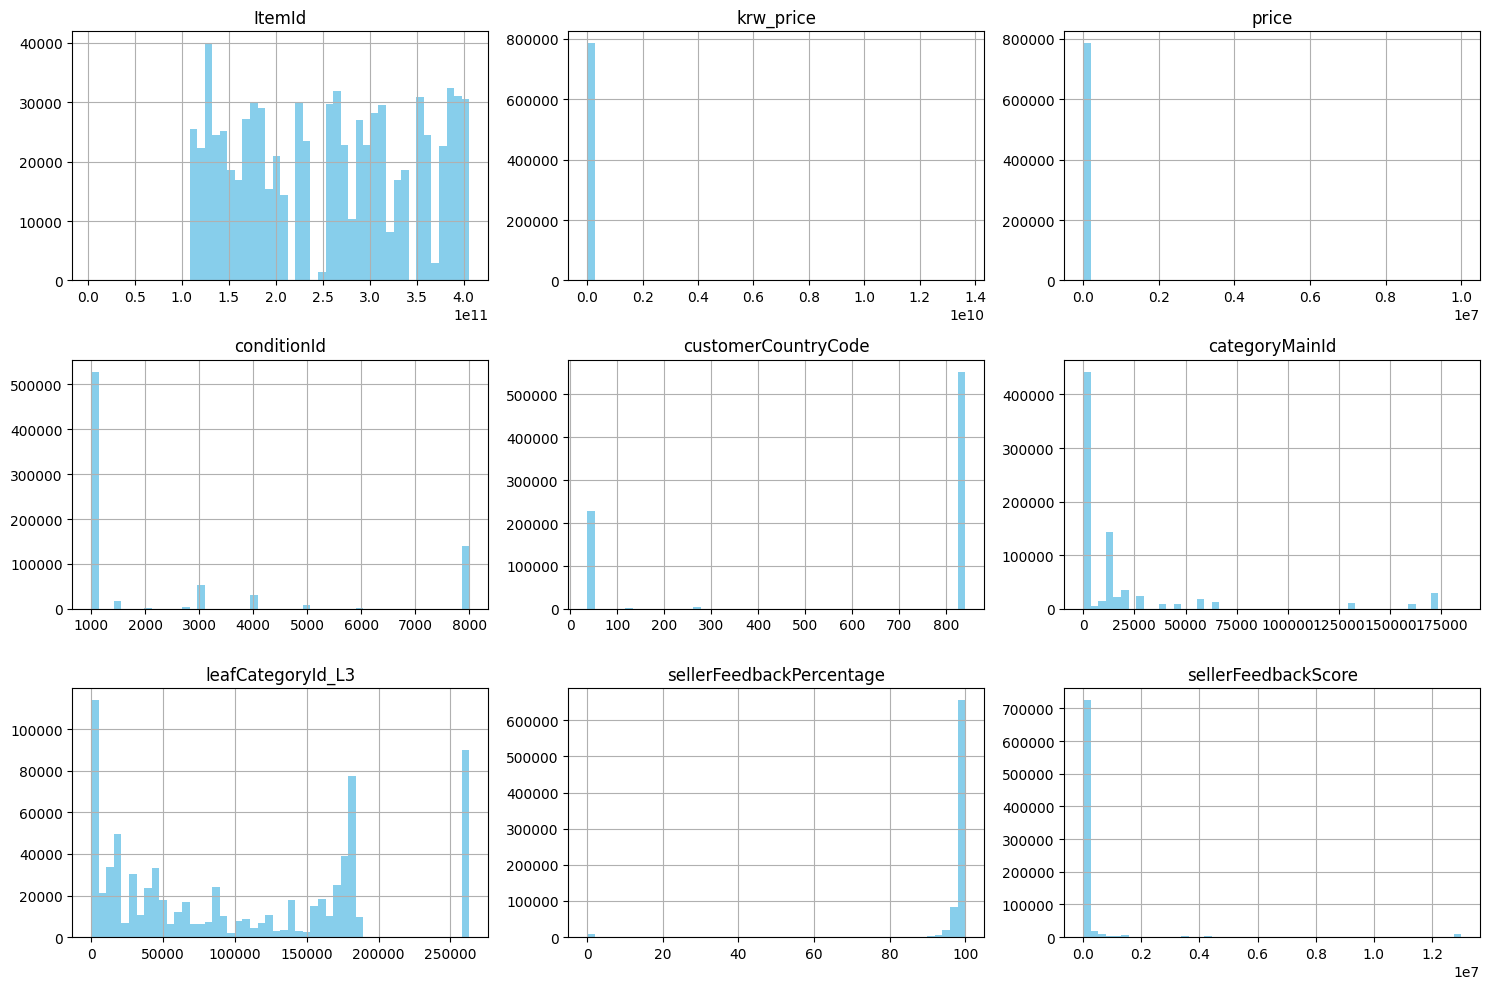

In [63]:
# 수치형 분포 보기
numeric_cols = df.select_dtypes(include='number').columns

df[numeric_cols].hist(bins=50, figsize=(15, 10), color='skyblue')
plt.tight_layout()
plt.show()

## 1.2 결측치 확인

In [64]:
# 결측치 확인
df.isnull().sum()

ItemId                           0
title                            0
krw_price                        0
price                            0
currency                         0
marketingPrice              701455
conditionEnumValue               0
condition                        0
conditionId                      0
adultOnly                        0
availableCoupons                 0
buyingOptions                    0
customerCountry                  0
customerCountryCode              0
image                            0
itemWebUrl                       0
itemLocation                     0
itemOriginDate                   0
itemCreationDate                 0
priorityListing                  0
topRatedBuyingExperience         0
categoryMainName                 0
categoryMainId                   0
leafCategoryName_L3              0
leafCategoryId_L3                0
listingMarketplaceId             0
sellerUsername                   0
sellerFeedbackPercentage         0
sellerFeedbackScore 

In [77]:
df['itemLocation_nonmask'] = df['itemLocation_nonmask'].fillna('Unknown')

In [78]:
df.isnull().sum()

ItemId                           0
title                            0
krw_price                        0
price                            0
currency                         0
marketingPrice              701455
conditionEnumValue               0
condition                        0
conditionId                      0
adultOnly                        0
availableCoupons                 0
buyingOptions                    0
customerCountry                  0
customerCountryCode              0
image                            0
itemWebUrl                       0
itemLocation                     0
itemOriginDate                   0
itemCreationDate                 0
priorityListing                  0
topRatedBuyingExperience         0
categoryMainName                 0
categoryMainId                   0
leafCategoryName_L3              0
leafCategoryId_L3                0
listingMarketplaceId             0
sellerUsername                   0
sellerFeedbackPercentage         0
sellerFeedbackScore 

## 1.3 이상치 처리

이미 했음 (그동안의 전처리 과정)

## 2. EDA 및 시각화

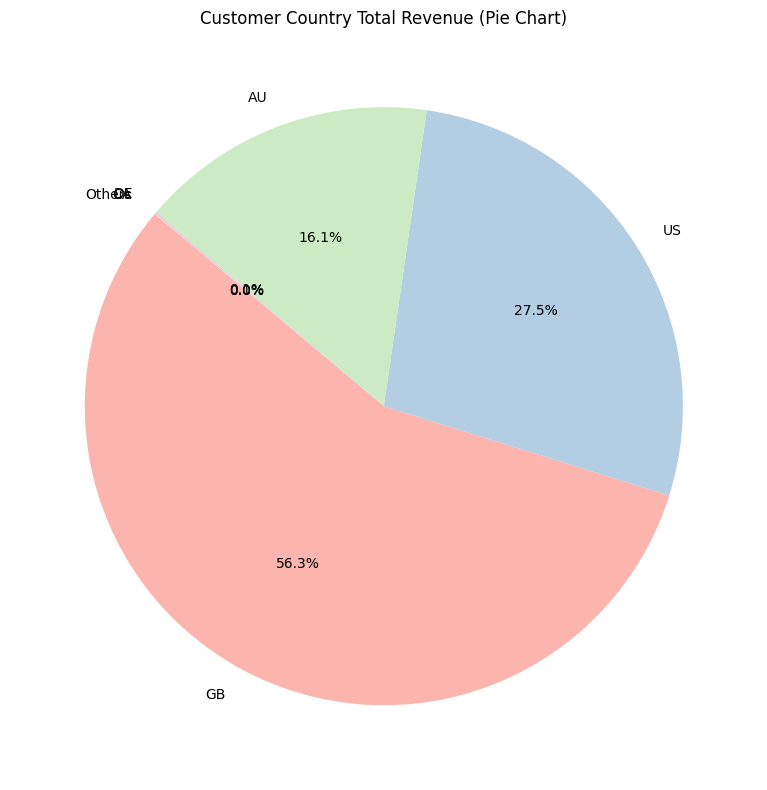

In [67]:
# 지역별 고객 총 매출
state_sales = df.groupby('customerCountry')['krw_price'].sum().sort_values(ascending=False)

# 상위 N개만 표시 (예: 상위 5개), 나머지는 'Others'로 묶기
top_n = 5
top_sales = state_sales[:top_n]
others = state_sales[top_n:].sum()
top_sales['Others'] = others

# 파이 차트 시각화
plt.figure(figsize=(8, 8))
plt.pie(
    top_sales.values,
    labels=top_sales.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Pastel1.colors
)
plt.title('Customer Country Total Revenue (Pie Chart)')
plt.tight_layout()
plt.show()


In [81]:
# 미국 주 풀네임 리스트
us_state_fullnames = [
    'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut',
    'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa',
    'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan',
    'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
    'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina',
    'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island',
    'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont',
    'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming'
]

# 미국 주인 경우만 'US' 할당
df['itemLocationCountry'] = df['state'].apply(lambda x: 'US' if x in us_state_fullnames else np.nan)

In [99]:
df.isnull().sum()

ItemId                           0
title                            0
krw_price                        0
price                            0
currency                         0
marketingPrice              701455
conditionEnumValue               0
condition                        0
conditionId                      0
adultOnly                        0
availableCoupons                 0
buyingOptions                    0
customerCountry                  0
customerCountryCode              0
image                            0
itemWebUrl                       0
itemLocation                     0
itemOriginDate                   0
itemCreationDate                 0
priorityListing                  0
topRatedBuyingExperience         0
categoryMainName                 0
categoryMainId                   0
leafCategoryName_L3              0
leafCategoryId_L3                0
listingMarketplaceId             0
sellerUsername                   0
sellerFeedbackPercentage         0
sellerFeedbackScore 

In [83]:
# 호주 주 풀네임 리스트
au_state_fullnames = [
    'New South Wales',
    'Victoria',
    'Queensland',
    'South Australia',
    'Western Australia',
    'Tasmania',
    'Northern Territory',
    'Australian Capital Territory' 
]

# state가 호주 주 이름이면 'AU', 아니면 그대로
df.loc[df['state'].isin(au_state_fullnames), 'itemLocationCountry'] = 'AU'


In [85]:
# 영국 구성 지역 리스트
uk_state_fullnames = ['England', 'Scotland', 'Wales', 'Northern Ireland']

# state가 이 중 하나면 'GB'로 설정
df.loc[df['state'].isin(uk_state_fullnames), 'itemLocationCountry'] = 'GB'


In [89]:
# 스페인
es_state_fullnames = [
    'Madrid',
    'Barcelona',
    'Malaga',
    'Seville',
    'Murcia',
    'Asturias',
    'Valencia',
    'A Coruna',
    'Las Palmas',
    'Balearic Islands',
    'Zaragoza'
]

df.loc[df['state'].isin(es_state_fullnames), 'itemLocationCountry'] = 'ES'

In [91]:
# 아일랜드
ie_state_fullnames = ['Dublin', 'Wicklow', 'Cork', 'Galway', 'Limerick']

df.loc[df['state'].isin(ie_state_fullnames), 'itemLocationCountry'] = 'IE'

In [105]:
# 독일

de_state_eng_to_native = {
    'Schleswig-Holstein': 'Schleswig-Holstein',
    'Mecklenburg-Vorpommern': 'Mecklenburg-Vorpommern',
    'Hamburg': 'Hamburg',
    'Lower Saxony': 'Niedersachsen',
    'North Rhine-Westphalia': 'Nordrhein-Westfalen',
    'Rhineland-Palatinate': 'Rheinland-Pfalz',
    'Hesse': 'Hessen',
    'Saarland': 'Saarland',
    'Baden-Württemberg': 'Baden-Württemberg',
    'Bavaria': 'Bayern',
    'Thuringia': 'Thüringen'
}

extra_de_state_eng_to_native = {
    'Sachsen-Anhalt': 'Sachsen-Anhalt',
    'Sachsen': 'Sachsen',
    'Thuringia': 'Thüringen',
    'Rheinland-Pfalz': 'Rheinland-Pfalz',
    'North Rhine-Westphalia': 'Nordrhein-Westfalen'
}

df['state'] = df['state'].replace(de_state_eng_to_native)
df['state'] = df['state'].replace(extra_de_state_eng_to_native)


de_state_native_names = list(set(de_state_eng_to_native.values()) | set(extra_de_state_eng_to_native.values()))


df.loc[df['state'].isin(de_state_native_names), 'itemLocationCountry'] = 'DE'


In [98]:
# 프랑스
fr_state_eng_to_native = {
    'Ile-de-France': 'Île-de-France',
    'Provence-Alpes-Cote dAzur': "Provence-Alpes-Côte d'Azur",
    'Occitanie': 'Occitanie',
    'Nouvelle-Aquitaine': 'Nouvelle-Aquitaine',
    'Pays de la Loire': 'Pays de la Loire',
    'Hauts-de-France': 'Hauts-de-France',
    'Auvergne-Rhone-Alpes': 'Auvergne-Rhône-Alpes',
    'Grand Est': 'Grand Est',
    'Bretagne': 'Bretagne',
    'Asine': 'Aisne',
    'Saone-et-Loire': 'Saône-et-Loire',
    'Pyrenees-Orientales': 'Pyrénées-Orientales',
    'Herault': 'Hérault',
    'Nievre': 'Nièvre',
    'Cote-d\'Or': "Côte-d'Or",
    'Haute-Saone': 'Haute-Saône',
    'Correze': 'Corrèze'
}

df['state'] = df['state'].replace(fr_state_eng_to_native)


# 프랑스어로 확정된 모든 지역 이름 리스트
fr_state_fullnames = [
    'Indre-et-Loire', 'Aisne', 'Aude', 'Oise', 'Manche',
    'Meurthe-et-Moselle', 'Loiret', 'Ardennes', 'Seine-Maritime',
    'Charente-Maritime', 'Aube', 'Calvados', 'Vienne',
    'Doubs', 'Hautes-Alpes', 'Alpes-Maritimes', 'Saône-et-Loire',
    'Pyrénées-Orientales', 'Eure-et-Loir', 'Meuse', 'Hérault',
    'Somme', 'Nièvre', "Côte-d'Or", 'Eure', 'Charente',
    'Haute-Vienne', 'Gard', 'Haute-Saône', 'Aveyron',
    'Corrèze', 'Haute-Marne'
]

df.loc[df['state'].isin(fr_state_fullnames), 'itemLocationCountry'] = 'FR'

In [100]:
# 프랑스 지명과 매칭되는 행만 추출
df_fr_check = df[df['state'].isin(fr_state_fullnames)].copy()
df_fr_check

,ItemId,title,krw_price,price,currency,marketingPrice,conditionEnumValue,condition,conditionId,adultOnly,...,sellerFeedbackPercentage,sellerFeedbackScore,sellerAccountType,shippingCostType,shippingCostValue,shippingCostCurrency,itemLocation_nonmask,areaCode,state,itemLocationCountry
2840,186499133120,LE PETIT JOURNAL 1891 N° 44 CHARLES TERRONT VI...,32018,17.38,GBP,NaN,UNSPECIFIED,unspecified,8000,False,...,99.50,14785,BUSINESS,FIXED,8.68,GBP,37,37,Indre-et-Loire,FR
3564,205516582097,Paul Crotto Poster Exhibition 1978 Galerie Ren...,350140,190.06,GBP,NaN,UNSPECIFIED,unspecified,8000,False,...,100.00,259,INDIVIDUAL,FIXED,21.12,GBP,02,02,Aisne,FR
4047,255029328065,Tulup Glass Print Wall Art Image Picture 140x7...,276321,149.99,GBP,NaN,NEW,new,1000,False,...,98.70,9462,BUSINESS,FIXED,20.0,GBP,02,02,Aisne,FR
7827,187012742442,2 Posters Print Art Print 1995 Ian Beck 40 x 3...,27818,15.10,GBP,NaN,UNSPECIFIED,unspecified,8000,False,...,100.00,137,INDIVIDUAL,FIXED,8.41,GBP,11,11,Aude,FR
24813,135612656911,Perplexity Ai PRO 12 Months subscription Accou...,15659,8.50,GBP,NaN,UNSPECIFIED,unspecified,8000,False,...,100.00,16,INDIVIDUAL,unknown,unknown,unknown,02,02,Aisne,FR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
758663,356445508728,LOT 4 TICKETS PORTUGAL REF17593J,38081,27.92,USD,NaN,UNSPECIFIED,unspecified,8000,False,...,99.70,34395,unknown,FIXED,0.0,USD,06,06,Alpes-Maritimes,FR
761323,356445508805,LOT 4 TICKETS PORTUGAL REF17592J,38081,27.92,USD,NaN,UNSPECIFIED,unspecified,8000,False,...,99.70,34395,unknown,FIXED,0.0,USD,06,06,Alpes-Maritimes,FR
768217,396578187417,One Piece Manga Notebook 12 Self-Adhesive Stam...,49879,36.57,USD,NaN,UNSPECIFIED,unspecified,8000,False,...,100.00,30368,unknown,FIXED,10.19,USD,06,06,Alpes-Maritimes,FR
770337,396688978550,"FRANCE STAMP YVERT 182 SCOTT 197 "" CONGRES PHI...",143159,104.96,USD,"{'originalPrice': {'value': '139.95', 'currenc...",UNSPECIFIED,unspecified,8000,False,...,99.90,49111,unknown,FIXED,9.0,USD,06,06,Alpes-Maritimes,FR


In [93]:
# 이탈리아
# 영문 → 이탈리아어 지역명 매핑
it_state_eng_to_native = {
    'Lazio': 'Lazio',
    'Liguria': 'Liguria',
    'Piedmont': 'Piemonte',
    'Lombardy': 'Lombardia',
    'Trentino-Alto Adige': 'Trentino-Alto Adige',
    'Veneto': 'Veneto',
    'Emilia-Romagna': 'Emilia-Romagna',
    'Tuscany': 'Toscana',
    'Marche': 'Marche',
    'Apulia': 'Puglia',
    'Campania': 'Campania',
    'Sicily': 'Sicilia',
    'Sardinia': 'Sardegna',
    'Molise': 'Molise'
}

it_state_fullnames = list(it_state_eng_to_native.values())
df.loc[df['state'].isin(it_state_fullnames), 'itemLocationCountry'] = 'IT'

In [106]:
df.isnull().sum()

ItemId                           0
title                            0
krw_price                        0
price                            0
currency                         0
marketingPrice              701455
conditionEnumValue               0
condition                        0
conditionId                      0
adultOnly                        0
availableCoupons                 0
buyingOptions                    0
customerCountry                  0
customerCountryCode              0
image                            0
itemWebUrl                       0
itemLocation                     0
itemOriginDate                   0
itemCreationDate                 0
priorityListing                  0
topRatedBuyingExperience         0
categoryMainName                 0
categoryMainId                   0
leafCategoryName_L3              0
leafCategoryId_L3                0
listingMarketplaceId             0
sellerUsername                   0
sellerFeedbackPercentage         0
sellerFeedbackScore 

In [124]:
df_null_country = df[df['itemLocationCountry'].isna()]

In [125]:
df_null_country = df_null_country[['itemLocationCountry', 'state']]
df_null_country['state'].value_counts()

state
Hauts-de-France    13
Name: count, dtype: int64

In [109]:
df.loc[df['state'].str.upper() == 'UNKNOWN', 'itemLocationCountry'] = 'UNKNOWN'

In [110]:
df.isnull().sum()

ItemId                           0
title                            0
krw_price                        0
price                            0
currency                         0
marketingPrice              701455
conditionEnumValue               0
condition                        0
conditionId                      0
adultOnly                        0
availableCoupons                 0
buyingOptions                    0
customerCountry                  0
customerCountryCode              0
image                            0
itemWebUrl                       0
itemLocation                     0
itemOriginDate                   0
itemCreationDate                 0
priorityListing                  0
topRatedBuyingExperience         0
categoryMainName                 0
categoryMainId                   0
leafCategoryName_L3              0
leafCategoryId_L3                0
listingMarketplaceId             0
sellerUsername                   0
sellerFeedbackPercentage         0
sellerFeedbackScore 

In [127]:
# 국가별 지명 수정 및 국가코드
state_country_map = {
    # 🇫🇷 프랑스
    'Île-de-France': ('Île-de-France', 'FR'),
    'Territoire de Belfort': ('Territoire de Belfort', 'FR'),
    'Allier': ('Allier', 'FR'),
    'Ardenness': ('Ardennes', 'FR'),
    'Pays de la Loire': ('Pays de la Loire', 'FR'),
    'Ain': ('Ain', 'FR'),
    'Auvergne-Rhône-Alpes': ('Auvergne-Rhône-Alpes', 'FR'),
    'Nouvelle-Aquitaine': ('Nouvelle-Aquitaine', 'FR'),
    'Provence-Alpes-Côte d\'Azur': ('Provence-Alpes-Côte d’Azur', 'FR'),
    'Alpes-de-Haute-Provence': ('Alpes-de-Haute-Provence', 'FR'),
    'Aredeche': ('Ardèche', 'FR'),
    'Essonne': ('Essonne', 'FR'),
    'Ariege': ('Ariège', 'FR'),
    'Ardeche': ('Ardèche', 'FR'),
    'Occitanie': ('Occitanie', 'FR'),
    'Grand Est': ('Grand Est', 'FR'),
    'Toulon': ('Toulon', 'FR'),
    'Val-de-Marne': ('Val-de-Marne', 'FR'),
    'Bretagne': ('Bretagne', 'FR'),
    'Tarn': ('Tarn', 'FR'),
    'Seine-Saint-Denis': ('Seine-Saint-Denis', 'FR'),
    'Vosges': ('Vosges', 'FR'),
    'Yonne': ('Yonne', 'FR'),
    'Val-d\'Oise': ('Val-d’Oise', 'FR'),
    'Vaucluse': ('Vaucluse', 'FR'),
    'Tarn-et-Garonne': ('Tarn-et-Garonne', 'FR'),
    'Hauts-de-France': ('Hauts-de-France', 'FR'),

    # 🇮🇹 이탈리아
    'Lombardy': ('Lombardia', 'IT'),
    'Piedmont': ('Piemonte', 'IT'),
    'Apulia': ('Puglia', 'IT'),
    'Tuscany': ('Toscana', 'IT'),
    'Sicily': ('Sicilia', 'IT'),
    'Sardinia': ('Sardegna', 'IT'),

    # 🇺🇸 예외 처리 (채우지 않음)
    'AE': ('Armed Forces Europe', 'US'),
    'PR': ('Puerto Rico', 'US'),
}

def map_state_and_country(row):
    if pd.isna(row['itemLocationCountry']) and row['state'] in state_country_map:
        new_state, new_country = state_country_map[row['state']]
        row['state'] = new_state
        row['itemLocationCountry'] = new_country
    return row

df = df.apply(map_state_and_country, axis=1)


In [128]:
df.isnull().sum()

ItemId                           0
title                            0
krw_price                        0
price                            0
currency                         0
marketingPrice              701455
conditionEnumValue               0
condition                        0
conditionId                      0
adultOnly                        0
availableCoupons                 0
buyingOptions                    0
customerCountry                  0
customerCountryCode              0
image                            0
itemWebUrl                       0
itemLocation                     0
itemOriginDate                   0
itemCreationDate                 0
priorityListing                  0
topRatedBuyingExperience         0
categoryMainName                 0
categoryMainId                   0
leafCategoryName_L3              0
leafCategoryId_L3                0
listingMarketplaceId             0
sellerUsername                   0
sellerFeedbackPercentage         0
sellerFeedbackScore 

In [129]:
df.to_csv('6.csv')

In [136]:
fr_df = df[df['itemLocationCountry'] == 'FR']

In [137]:
fr_df['state'].value_counts()

state
Grand Est                     518
Provence-Alpes-Côte d’Azur    152
Auvergne-Rhône-Alpes          152
Hauts-de-France                95
Île-de-France                  89
Bourgogne-Franche-Comté        86
Pays de la Loire               53
Nouvelle-Aquitaine             47
Occitanie                      32
Centre-Val de Loire            24
Normandie                      12
Bretagne                        5
Toulon                          5
Name: count, dtype: int64

In [135]:
# 재시작된 세션에서 다시 실행
import pandas as pd

# 전체 départements -> régions 매핑 딕셔너리 준비 (프랑스 본토 13개 지역 기준)
fr_dept_to_region = {
    'Ain': 'Auvergne-Rhône-Alpes', 'Allier': 'Auvergne-Rhône-Alpes', 'Ardèche': 'Auvergne-Rhône-Alpes',
    'Cantal': 'Auvergne-Rhône-Alpes', 'Drôme': 'Auvergne-Rhône-Alpes', 'Isère': 'Auvergne-Rhône-Alpes',
    'Loire': 'Auvergne-Rhône-Alpes', 'Haute-Loire': 'Auvergne-Rhône-Alpes', 'Puy-de-Dôme': 'Auvergne-Rhône-Alpes',
    'Rhône': 'Auvergne-Rhône-Alpes', 'Savoie': 'Auvergne-Rhône-Alpes', 'Haute-Savoie': 'Auvergne-Rhône-Alpes',
    'Côte-d\'Or': 'Bourgogne-Franche-Comté', 'Doubs': 'Bourgogne-Franche-Comté', 'Jura': 'Bourgogne-Franche-Comté',
    'Nièvre': 'Bourgogne-Franche-Comté', 'Haute-Saône': 'Bourgogne-Franche-Comté', 'Saône-et-Loire': 'Bourgogne-Franche-Comté',
    'Yonne': 'Bourgogne-Franche-Comté', 'Territoire de Belfort': 'Bourgogne-Franche-Comté',
    'Côtes-d\'Armor': 'Bretagne', 'Finistère': 'Bretagne', 'Ille-et-Vilaine': 'Bretagne', 'Morbihan': 'Bretagne',
    'Cher': 'Centre-Val de Loire', 'Eure-et-Loir': 'Centre-Val de Loire', 'Indre': 'Centre-Val de Loire',
    'Indre-et-Loire': 'Centre-Val de Loire', 'Loir-et-Cher': 'Centre-Val de Loire', 'Loiret': 'Centre-Val de Loire',
    'Corse-du-Sud': 'Corse', 'Haute-Corse': 'Corse',
    'Ardennes': 'Grand Est', 'Aube': 'Grand Est', 'Marne': 'Grand Est', 'Haute-Marne': 'Grand Est',
    'Meurthe-et-Moselle': 'Grand Est', 'Meuse': 'Grand Est', 'Moselle': 'Grand Est', 'Bas-Rhin': 'Grand Est',
    'Haut-Rhin': 'Grand Est', 'Vosges': 'Grand Est',
    'Aisne': 'Hauts-de-France', 'Nord': 'Hauts-de-France', 'Oise': 'Hauts-de-France',
    'Pas-de-Calais': 'Hauts-de-France', 'Somme': 'Hauts-de-France',
    'Paris': 'Île-de-France', 'Seine-et-Marne': 'Île-de-France', 'Yvelines': 'Île-de-France',
    'Essonne': 'Île-de-France', 'Hauts-de-Seine': 'Île-de-France', 'Seine-Saint-Denis': 'Île-de-France',
    'Val-de-Marne': 'Île-de-France', 'Val-d’Oise': 'Île-de-France',
    'Calvados': 'Normandie', 'Eure': 'Normandie', 'Manche': 'Normandie', 'Orne': 'Normandie',
    'Seine-Maritime': 'Normandie',
    'Charente': 'Nouvelle-Aquitaine', 'Charente-Maritime': 'Nouvelle-Aquitaine', 'Corrèze': 'Nouvelle-Aquitaine',
    'Creuse': 'Nouvelle-Aquitaine', 'Dordogne': 'Nouvelle-Aquitaine', 'Gironde': 'Nouvelle-Aquitaine',
    'Landes': 'Nouvelle-Aquitaine', 'Lot-et-Garonne': 'Nouvelle-Aquitaine', 'Pyrénées-Atlantiques': 'Nouvelle-Aquitaine',
    'Deux-Sèvres': 'Nouvelle-Aquitaine', 'Vienne': 'Nouvelle-Aquitaine', 'Haute-Vienne': 'Nouvelle-Aquitaine',
    'Ariège': 'Occitanie', 'Aude': 'Occitanie', 'Aveyron': 'Occitanie', 'Gard': 'Occitanie', 'Haute-Garonne': 'Occitanie',
    'Gers': 'Occitanie', 'Hérault': 'Occitanie', 'Lot': 'Occitanie', 'Lozère': 'Occitanie', 'Hautes-Pyrénées': 'Occitanie',
    'Pyrénées-Orientales': 'Occitanie', 'Tarn': 'Occitanie', 'Tarn-et-Garonne': 'Occitanie',
    'Loire-Atlantique': 'Pays de la Loire', 'Maine-et-Loire': 'Pays de la Loire', 'Mayenne': 'Pays de la Loire',
    'Sarthe': 'Pays de la Loire', 'Vendée': 'Pays de la Loire',
    'Alpes-de-Haute-Provence': 'Provence-Alpes-Côte d’Azur', 'Hautes-Alpes': 'Provence-Alpes-Côte d’Azur',
    'Alpes-Maritimes': 'Provence-Alpes-Côte d’Azur', 'Bouches-du-Rhône': 'Provence-Alpes-Côte d’Azur',
    'Var': 'Provence-Alpes-Côte d’Azur', 'Vaucluse': 'Provence-Alpes-Côte d’Azur'
}

# 2. 매핑 함수 정의
def map_fr_region(state):
    return fr_dept_to_region.get(state, state)  # 없으면 그대로 유지

# 3. 적용
df['state'] = df['state'].apply(map_fr_region)


In [145]:
es_df = df[df['itemLocationCountry'] == 'ES']
es_df

,ItemId,title,krw_price,price,currency,marketingPrice,conditionEnumValue,condition,conditionId,adultOnly,...,sellerFeedbackPercentage,sellerFeedbackScore,sellerAccountType,shippingCostType,shippingCostValue,shippingCostCurrency,itemLocation_nonmask,areaCode,state,itemLocationCountry
123903,334421912868,"ORIGINAL ROLEX PART REPLACEMENT CALIBER.2235, ...",105340,57.18,GBP,NaN,UNSPECIFIED,unspecified,1500,False,...,99.90,10385,BUSINESS,FIXED,8.38,GBP,28,28,Madrid,ES
125967,273922355868,"1 PC FEF Full Steering Wheel, Complete Balance...",28002,15.20,GBP,NaN,UNSPECIFIED,unspecified,1500,False,...,99.50,20538,BUSINESS,FIXED,4.05,GBP,08,08,Cataluña,ES
126027,274317647952,NOS New 1Pc ST Standard FHF 69 RND: 1292 401 W...,6006,3.26,GBP,"{'originalPrice': {'value': '5.02', 'currency'...",UNSPECIFIED,unspecified,1500,False,...,99.50,20538,BUSINESS,FIXED,3.35,GBP,33,33,Asturias,ES
126234,273647994168,[1X] NOS Omega Balance staff steering wheel ax...,13872,7.53,GBP,NaN,UNSPECIFIED,unspecified,1500,False,...,99.50,20538,BUSINESS,FIXED,3.35,GBP,33,33,Asturias,ES
254540,167513742246,Pokemon TCG Pocket / Trade any 3 Diamond Card ...,3355,2.46,USD,NaN,NEW,new,1000,False,...,100.00,170,unknown,FIXED,0.0,USD,08,08,Cataluña,ES
254560,167473733650,Pokemon TCG Pocket / Trade any EX 4 Diamond Ca...,1555,1.14,USD,NaN,NEW,new,1000,False,...,100.00,170,unknown,FIXED,0.0,USD,08,08,Cataluña,ES
256432,167476851843,Pokemon TCG Pocket / Trade any 1 STAR Card Sel...,5442,3.99,USD,NaN,UNSPECIFIED,unspecified,8000,False,...,100.00,170,unknown,FIXED,0.0,USD,08,08,Cataluña,ES
736905,124792011277,Decals Porsche 911 S Le Mans 1970 1:32 1:24 1:...,14267,10.46,USD,NaN,NEW,new,1000,False,...,99.50,20456,unknown,FIXED,4.0,USD,03,03,Valencia,ES
738138,126487901079,1970 Porsche 911 S Le Mans Decals 1:32 1:24 1:...,14267,10.46,USD,NaN,NEW,new,1000,False,...,99.50,20456,unknown,FIXED,4.0,USD,03,03,Valencia,ES
738140,124789967685,1966 Porsche 906 Le Mans Decals 1:32 1:43 1:24...,14267,10.46,USD,NaN,NEW,new,1000,False,...,99.50,20456,unknown,FIXED,4.0,USD,03,03,Valencia,ES


In [144]:
es_province_to_region = {
    'A Coruña': 'Galicia',
    'Álava': 'País Vasco',
    'Albacete': 'Castilla-La Mancha',
    'Alicante': 'Comunidad Valenciana',
    'Almería': 'Andalucía',
    'Asturias': 'Asturias',
    'Ávila': 'Castilla y León',
    'Badajoz': 'Extremadura',
    'Barcelona': 'Cataluña',
    'Burgos': 'Castilla y León',
    'Cáceres': 'Extremadura',
    'Cádiz': 'Andalucía',
    'Cantabria': 'Cantabria',
    'Castellón': 'Comunidad Valenciana',
    'Ciudad Real': 'Castilla-La Mancha',
    'Córdoba': 'Andalucía',
    'Cuenca': 'Castilla-La Mancha',
    'Girona': 'Cataluña',
    'Granada': 'Andalucía',
    'Guadalajara': 'Castilla-La Mancha',
    'Guipúzcoa': 'País Vasco',
    'Huelva': 'Andalucía',
    'Huesca': 'Aragón',
    'Illes Balears': 'Islas Baleares',
    'Jaén': 'Andalucía',
    'La Rioja': 'La Rioja',
    'Las Palmas': 'Canarias',
    'León': 'Castilla y León',
    'Lleida': 'Cataluña',
    'Lugo': 'Galicia',
    'Comunidad de Madrid': 'Madrid',
    'Málaga': 'Andalucía',
    'Murcia': 'Región de Murcia',
    'Navarra': 'Navarra',
    'Ourense': 'Galicia',
    'Palencia': 'Castilla y León',
    'Pontevedra': 'Galicia',
    'Salamanca': 'Castilla y León',
    'Santa Cruz de Tenerife': 'Canarias',
    'Segovia': 'Castilla y León',
    'Sevilla': 'Andalucía',
    'Soria': 'Castilla y León',
    'Tarragona': 'Cataluña',
    'Teruel': 'Aragón',
    'Toledo': 'Castilla-La Mancha',
    'Comunidad Valenciana': 'Valencia',
    'Valladolid': 'Castilla y León',
    'Vizcaya': 'País Vasco',
    'Zamora': 'Castilla y León',
    'Zaragoza': 'Aragón',
    'Ceuta': 'Ceuta',
    'Melilla': 'Melilla'
}

def map_es_region(state):
    return es_province_to_region.get(state, state)  # 없으면 그대로 반환

df['state'] = df['state'].apply(map_es_region)


In [147]:
it_df = df[df['itemLocationCountry'] == 'IT']
it_df

,ItemId,title,krw_price,price,currency,marketingPrice,conditionEnumValue,condition,conditionId,adultOnly,...,sellerFeedbackPercentage,sellerFeedbackScore,sellerAccountType,shippingCostType,shippingCostValue,shippingCostCurrency,itemLocation_nonmask,areaCode,state,itemLocationCountry
58614,305919961535,NEO GEO MVS 2 slot like new MV2FS,311250,168.95,GBP,NaN,UNSPECIFIED,unspecified,1000,False,...,0.00,211,INDIVIDUAL,FIXED,29.57,GBP,21,21,Trentino-Alto Adige,IT
72218,388355508780,Tauntaun Cuddles Set 13 4 Star Tauntaun Cuddly...,2800,1.52,GBP,NaN,UNSPECIFIED,unspecified,1000,False,...,100.00,77,INDIVIDUAL,FIXED,0.0,GBP,70,70,Puglia,IT
72928,388355538096,Jawa Jackpot Set 14 4 Star Jackpot Jawa Mono_p...,2800,1.52,GBP,NaN,UNSPECIFIED,unspecified,1000,False,...,100.00,77,INDIVIDUAL,FIXED,0.0,GBP,70,70,Puglia,IT
73213,388355519030,Purrgil Pursuit Set 13 4 Star Purrgil In Vista,2800,1.52,GBP,NaN,UNSPECIFIED,unspecified,1000,False,...,100.00,77,INDIVIDUAL,FIXED,0.0,GBP,70,70,Puglia,IT
73417,386484539128,FERRARI MODELS FORMULA 1 F1 AUTO COLLECTION 1/...,46683,25.34,GBP,NaN,UNSPECIFIED,unspecified,1000,False,...,100.00,1245,BUSINESS,FIXED,10.14,GBP,00,00,Lazio,IT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763490,290865485735,"Car Audio ""Nakamichi"" T-Shirt",24974,18.31,USD,NaN,UNSPECIFIED,unspecified,1000,False,...,100.00,3751,unknown,FIXED,21.74,USD,87,87,Molise,IT
764071,161627091971,WRITTEN SHELDON Cooper BigBang Theory Nerd Gee...,26379,19.34,USD,NaN,UNSPECIFIED,unspecified,1000,False,...,100.00,1720,unknown,FIXED,18.31,USD,60,60,Marche,IT
764645,275812968799,Galizio Torresi 440120 Lace Up Sneakers,349551,256.28,USD,NaN,UNSPECIFIED,unspecified,1000,False,...,83.30,1092,unknown,unknown,unknown,unknown,03,03,Piemonte,IT
765754,363337130161,Men's Enclosed Leather Fishing Sandals Sizes 4...,77867,57.09,USD,NaN,UNSPECIFIED,unspecified,1000,False,...,98.90,1082,unknown,FIXED,19.39,USD,72,72,Puglia,IT


In [148]:
it_df['state'].value_counts()

state
Molise                 90
Lazio                  70
Liguria                36
Lombardia              31
Emilia-Romagna         25
Piemonte               23
Puglia                 19
Campania               17
Trentino-Alto Adige     7
Toscana                 7
Sicilia                 6
Veneto                  6
Marche                  4
Sardegna                1
Name: count, dtype: int64

In [149]:
de_df = df[df['itemLocationCountry'] == 'DE']
de_df

,ItemId,title,krw_price,price,currency,marketingPrice,conditionEnumValue,condition,conditionId,adultOnly,...,sellerFeedbackPercentage,sellerFeedbackScore,sellerAccountType,shippingCostType,shippingCostValue,shippingCostCurrency,itemLocation_nonmask,areaCode,state,itemLocationCountry
487,405926147541,PHOTO NO. 45 - CLAUDIA SCHIFFER - GLOSSY FINIS...,2800,1.52,GBP,NaN,NEW,new,1000,False,...,100.00,1449,INDIVIDUAL,FIXED,1.52,GBP,18,18,Mecklenburg-Vorpommern,DE
586,126905738658,"REBECCA CAMPBELL: ""Jimmy Choo'd"", 2013, Rare A...",6264,3.40,GBP,NaN,NEW,new,1000,False,...,100.00,8122,BUSINESS,FIXED,4.26,GBP,52,52,Nordrhein-Westfalen,DE
649,405926147555,PHOTO NO. 50 - CLAUDIA SCHIFFER - GLOSSY FINIS...,2800,1.52,GBP,NaN,NEW,new,1000,False,...,100.00,1449,INDIVIDUAL,FIXED,1.52,GBP,18,18,Mecklenburg-Vorpommern,DE
799,405926147566,PHOTO NO. 44 - CLAUDIA SCHIFFER - GLOSSY FINIS...,2800,1.52,GBP,NaN,NEW,new,1000,False,...,100.00,1449,INDIVIDUAL,FIXED,1.52,GBP,18,18,Mecklenburg-Vorpommern,DE
828,127004593331,"Helga Anders, Steinsee, 1971, Rare Art Postcard",6264,3.40,GBP,NaN,NEW,new,1000,False,...,100.00,8122,BUSINESS,FIXED,4.26,GBP,52,52,Nordrhein-Westfalen,DE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
775140,205470562730,CENTRAL AFRICA 2025 MNH ** Homage to Pope Fran...,11307,8.29,USD,NaN,UNSPECIFIED,unspecified,8000,False,...,100.00,12389,unknown,FIXED,3.15,USD,49,49,Nordrhein-Westfalen,DE
775170,395718745220,"Romania 2022, Series ""Personalities"", **/MNH, ...",85669,62.81,USD,NaN,UNSPECIFIED,unspecified,8000,False,...,100.00,20641,unknown,FIXED,9.15,USD,96,96,Bayern,DE
775192,365363496920,AUSTRIA FIELD POST ITALY DELIVERY STAMPS 1918 ...,6220,4.56,USD,NaN,UNSPECIFIED,unspecified,8000,False,...,99.90,73261,unknown,FIXED,2.29,USD,35,35,Niedersachsen,DE
775274,362536289122,PORTUGAL 1967 1026-1048 ** MINT YEAR COMPLETE ...,7161,5.25,USD,NaN,UNSPECIFIED,unspecified,8000,False,...,99.90,73261,unknown,FIXED,2.29,USD,35,35,Niedersachsen,DE


In [151]:
de_df['state'].value_counts()

state
Sachsen-Anhalt            532
Niedersachsen             236
Hamburg                   186
Nordrhein-Westfalen       166
Baden-Württemberg         142
Bayern                    128
Schleswig-Holstein         94
Mecklenburg-Vorpommern     89
Hessen                     55
Rheinland-Pfalz            44
Sachsen                    38
Thüringen                  37
Saarland                   18
Name: count, dtype: int64

In [152]:
ie_df = df[df['itemLocationCountry'] == 'IE']
ie_df

,ItemId,title,krw_price,price,currency,marketingPrice,conditionEnumValue,condition,conditionId,adultOnly,...,sellerFeedbackPercentage,sellerFeedbackScore,sellerAccountType,shippingCostType,shippingCostValue,shippingCostCurrency,itemLocation_nonmask,areaCode,state,itemLocationCountry


In [153]:
df.to_csv('e-bay_tableau.csv')